In [1]:
import pandas as pd

info = pd.read_csv("studentInfo.csv")
assess = pd.read_csv("studentAssessment.csv")
vle = pd.read_csv("studentVle.csv")

### -info-

In [2]:
print(info.head())

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60          N         Pass  

In [3]:
print(info.columns)


Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result'],
      dtype='object')


### -asess-

In [4]:
print(assess.head())

   id_assessment  id_student  date_submitted  is_banked score
0           1752       11391              18          0    78
1           1752       28400              22          0    70
2           1752       31604              17          0    72
3           1752       32885              26          0    69
4           1752       38053              19          0    79


In [5]:
print(assess.columns)

Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], dtype='object')


In [6]:
# 점수 분포
assess['score'].describe()

# 성과 분포
info['final_result'].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

### -vle-

In [7]:
print(vle.head())

  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


In [8]:
print(vle.columns)

Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='object')


In [9]:
vle = vle[['id_student', 'date', 'sum_click']]
print(vle.head())

   id_student  date  sum_click
0       28400   -10          4
1       28400   -10          1
2       28400   -10          1
3       28400   -10         11
4       28400   -10          1


In [10]:
## 날짜별 클릭 합치기
daily_click = vle.groupby(['id_student', 'date'])['sum_click'].sum().reset_index()
print(daily_click.head())

   id_student  date  sum_click
0        6516   -23         28
1        6516   -22         82
2        6516   -20         41
3        6516   -17          7
4        6516   -12          2


In [11]:
## 날짜별 평균 클릭 계산
avg_click = daily_click.groupby('date')['sum_click'].mean().reset_index()
print(avg_click.head())

   date  sum_click
0   -25  25.052347
1   -24  26.304900
2   -23  20.332604
3   -22  16.865269
4   -21  12.726277


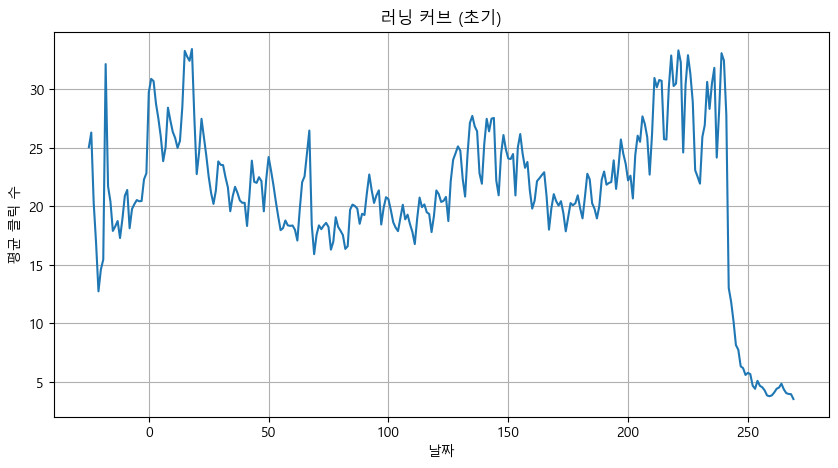

In [12]:

## 한글 안 깨지게
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 러닝커브 그래프 생성
plt.figure(figsize=(10,5))
plt.plot(avg_click['date'], avg_click['sum_click'])

plt.xlabel("날짜")
plt.ylabel("평균 클릭 수")
plt.title("러닝 커브 (초기)")

plt.grid(True)
plt.show()


#### 마지막 부분 급락 -> 학생 수가 적어서 평균 왜곡 -> 학생이 충분히 많은 날짜만 사용해야 됨

In [13]:
# 날짜별 학생 수 계산
count_per_day = daily_click.groupby('date')['id_student'].nunique().reset_index()
count_per_day.columns = ['date', 'num_students']

print(count_per_day.head())

   date  num_students
0   -25           554
1   -24           551
2   -23           457
3   -22           334
4   -21           274


In [14]:

## 학생 수 기준 필터
valid_days = count_per_day[count_per_day['num_students'] >= 200]['date']
filtered = daily_click[daily_click['date'].isin(valid_days)]

## 평균 계산
avg_click_filtered = filtered.groupby('date')['sum_click'].mean().reset_index()

## 학습 구간만 사용 (학습 종류 후x)
avg_click_filtered = avg_click_filtered[avg_click_filtered['date'] <= 200]
avg_click_filtered = avg_click_filtered[avg_click_filtered['sum_click'] > 5]

## 이동평균
avg_click_filtered['smoothed'] = avg_click_filtered['sum_click'].rolling(window=7, min_periods=1).mean()


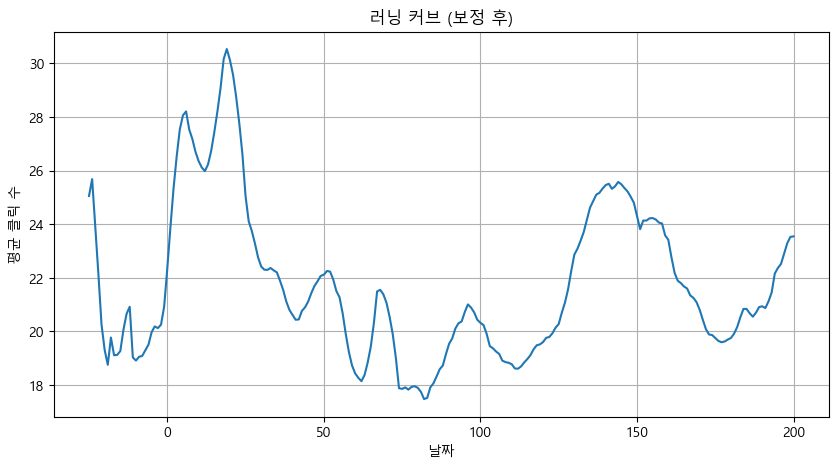

In [15]:

## 한글 안 깨지게
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 그래프 생성
plt.figure(figsize=(10,5))
plt.plot(avg_click_filtered['date'], avg_click_filtered['smoothed'])

plt.xlabel("날짜")
plt.ylabel("평균 클릭 수")
plt.title("러닝 커브 (보정 후)")

plt.grid(True)
plt.show()


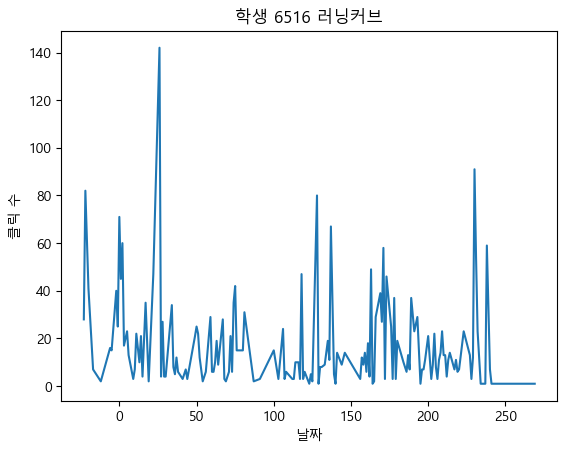

In [16]:

student_id = daily_click['id_student'].iloc[0]

one = daily_click[daily_click['id_student'] == student_id].sort_values('date')

plt.plot(one['date'], one['sum_click'])
plt.xlabel("날짜")
plt.ylabel("클릭 수")
plt.title(f"학생 {student_id} 러닝커브")
plt.show()


In [17]:
one = one.sort_values('date')

one['cumulative_click'] = one['sum_click'].cumsum()

## 누적으로 사용

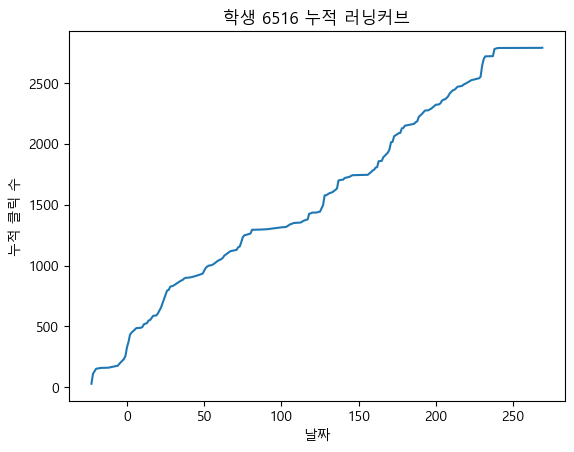

In [18]:
plt.plot(one['date'], one['cumulative_click'])

plt.xlabel("날짜")
plt.ylabel("누적 클릭 수")
plt.title(f"학생 {student_id} 누적 러닝커브")

plt.show()

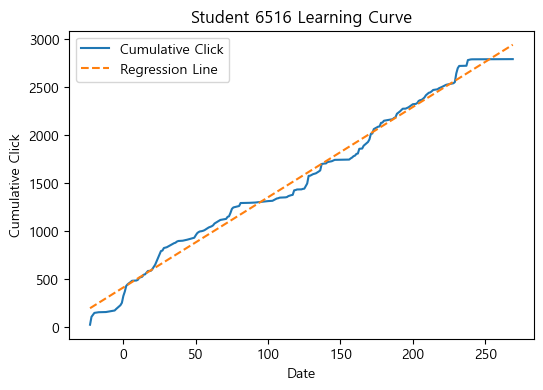

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x = one['date']
y = one['cumulative_click']

# 회귀선 계산
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

# 그래프
plt.figure(figsize=(6,4))

plt.plot(x, y, label='Cumulative Click')
plt.plot(x, poly1d_fn(x), linestyle='--', label='Regression Line')

plt.xlabel("Date")
plt.ylabel("Cumulative Click")
plt.title(f"Student {student_id} Learning Curve")

plt.legend()
plt.show()

## 누적

In [20]:
## 학생별 날짜순 정령
daily_click = daily_click.sort_values(['id_student', 'date'])
print(daily_click.head())

   id_student  date  sum_click
0        6516   -23         28
1        6516   -22         82
2        6516   -20         41
3        6516   -17          7
4        6516   -12          2


In [21]:
## 학생별 누적 클릭
daily_click['cumulative_click'] = daily_click.groupby('id_student')['sum_click'].cumsum()
print(daily_click.head(10))

   id_student  date  sum_click  cumulative_click
0        6516   -23         28                28
1        6516   -22         82               110
2        6516   -20         41               151
3        6516   -17          7               158
4        6516   -12          2               160
5        6516    -6         16               176
6        6516    -5         15               191
7        6516    -2         40               231
8        6516    -1         25               256
9        6516     0         71               327


In [22]:
## 학생 한 명으로 slope 테스트
import numpy as np

# 한 명 선택
student_id = daily_click['id_student'].iloc[0]

one = daily_click[daily_click['id_student'] == student_id]

x = one['date']
y = one['cumulative_click']

slope = np.polyfit(x, y, 1)[0]

print("학습 속도:", slope)

학습 속도: 9.386919547942004


In [23]:
## 전체 학생 학습 속도 계산
import numpy as np

students = daily_click['id_student'].unique()

results = []

for student in students:
    one = daily_click[daily_click['id_student'] == student]
    
    # 데이터 너무 적은 학생 제외
    if len(one) < 5:
        continue
    
    x = one['date']
    y = one['cumulative_click']
    
    slope = np.polyfit(x, y, 1)[0]
    
    results.append([student, slope])

# dataframe 만들기
learning_df = pd.DataFrame(results, columns=['id_student', 'learning_speed'])

print(learning_df.head())

   id_student  learning_speed
0        6516        9.386920
1        8462        4.588954
2       11391        2.430395
3       23629        1.460563
4       23698        3.146588


In [24]:
## K-means 군집화
from sklearn.cluster import KMeans

# feature 준비
X = learning_df[['learning_speed']]

# KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
learning_df['cluster'] = kmeans.fit_predict(X)

print(learning_df.head())

   id_student  learning_speed  cluster
0        6516        9.386920        0
1        8462        4.588954        1
2       11391        2.430395        1
3       23629        1.460563        1
4       23698        3.146588        1


In [25]:
'''
## K-means 군집화 시각화
import matplotlib.pyplot as plt

plt.scatter(learning_df['id_student'], learning_df['learning_speed']=learning_df['cluster'])
plt.xlabel("학생 ID")
plt.ylabel("학습 속도")
plt.title("학습 속도 군집화")
plt.show()
'''

'\n## K-means 군집화 시각화\nimport matplotlib.pyplot as plt\n\nplt.scatter(learning_df[\'id_student\'], learning_df[\'learning_speed\']=learning_df[\'cluster\'])\nplt.xlabel("학생 ID")\nplt.ylabel("학습 속도")\nplt.title("학습 속도 군집화")\nplt.show()\n'

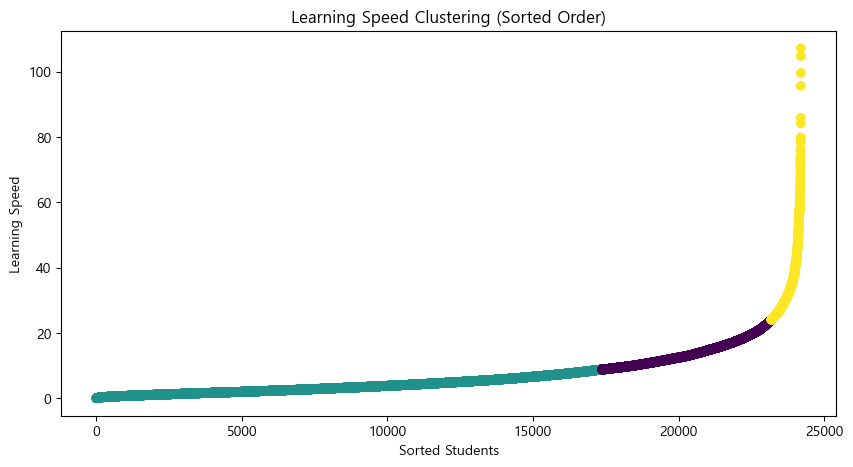

In [44]:
sorted_df = learning_df.sort_values('learning_speed')

plt.figure(figsize=(10,5))
plt.scatter(range(len(sorted_df)), sorted_df['learning_speed'], c=sorted_df['cluster'])

plt.xlabel("Sorted Students")
plt.ylabel("Learning Speed")
plt.title("Learning Speed Clustering (Sorted Order)")

plt.show()

그래프 해석

-> 핵심 패턴:

1. 대부분 학생
→ 학습 속도 낮음 (~0~10)

2. 일부 학생
→ 중간 (~10~25)

3. 소수 학생
→ 매우 높음 (25 이상)

** = 비대칭 분포 (long tail)

학습 속도 분포는 대부분의 사용자가 낮은 값을 가지며, 일부 사용자만 높은 학습 속도를 보이는 비대칭적인 형태를 나타냈다.

군집 해석

-> 색 기준으로 보면

초록: 느린 학습자
보라: 중간
노랑: 빠른 학습자


In [27]:
## 성적 연결
assess = pd.read_csv("studentAssessment.csv")
assess['score'] = pd.to_numeric(assess['score'], errors='coerce')
student_score = assess.groupby('id_student')['score'].mean().reset_index()

final_df = pd.merge(learning_df, student_score, on='id_student')
print(final_df.head())

   id_student  learning_speed  cluster      score
0        6516        9.386920        0  61.800000
1        8462        4.588954        1  87.000000
2       11391        2.430395        1  82.000000
3       23629        1.460563        1  82.500000
4       23698        3.146588        1  74.444444


In [28]:
final_df.groupby('cluster')['score'].mean()

cluster
0    77.823811
1    71.332541
2    81.597630
Name: score, dtype: float64

In [29]:
## (학습 속도 기준) 클러스터 재정렬
cluster_order = learning_df.groupby('cluster')['learning_speed'].mean().sort_values()
print(cluster_order)

cluster
1     3.685775
0    13.948098
2    34.089381
Name: learning_speed, dtype: float64


In [30]:
# 순서대로 번호 다시 붙이기
new_labels = {old: new for new, old in enumerate(cluster_order.index)}

learning_df['cluster_re'] = learning_df['cluster'].map(new_labels)

print(learning_df.head())

   id_student  learning_speed  cluster  cluster_re
0        6516        9.386920        0           1
1        8462        4.588954        1           0
2       11391        2.430395        1           0
3       23629        1.460563        1           0
4       23698        3.146588        1           0


In [31]:
## 성적 데이터에도 적용
final_df['cluster_re'] = final_df['cluster'].map(new_labels)

## 다시 평균 비교
final_df.groupby('cluster_re')['score'].mean()

cluster_re
0    71.332541
1    77.823811
2    81.597630
Name: score, dtype: float64

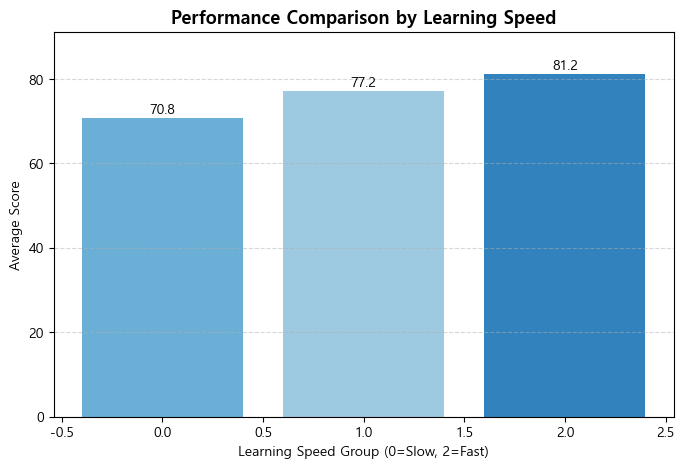

In [45]:
import matplotlib.pyplot as plt

result = final_df.groupby('cluster_re')['score'].mean()

plt.figure(figsize=(8,5))

bars = plt.bar(result.index, result.values,
               color=['#6baed6', '#9ecae1', '#3182bd'])

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f'{height:.1f}',
             ha='center', fontsize=10)

plt.xlabel("Learning Speed Group (0=Slow, 2=Fast)")
plt.ylabel("Average Score")
plt.title("Performance Comparison by Learning Speed", 
          fontsize=13, fontweight='bold')

plt.ylim(0, max(result.values)+10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

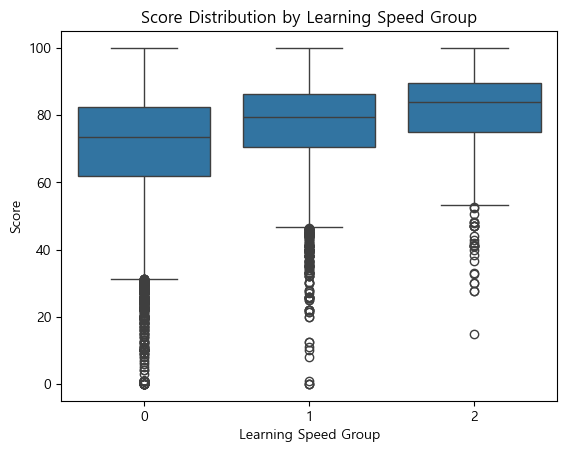

In [46]:
## Boxplot
import seaborn as sns

sns.boxplot(x='cluster_re', y='score', data=final_df)

plt.xlabel("Learning Speed Group")
plt.ylabel("Score")
plt.title("Score Distribution by Learning Speed Group")

plt.show()

## 군집별 학생 수

In [34]:
final_df['cluster_re'].value_counts()

cluster_re
0    16354
1     5637
2      987
Name: count, dtype: int64

In [35]:
from scipy.stats import f_oneway

g0 = final_df[final_df['cluster_re'] == 0]['score']
g1 = final_df[final_df['cluster_re'] == 1]['score']
g2 = final_df[final_df['cluster_re'] == 2]['score']

f_stat, p_value = f_oneway(g0, g1, g2)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: nan
p-value: nan


In [36]:
info = pd.read_csv("studentInfo.csv")
print(info.head())

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60          N         Pass  

In [37]:
info = info[['id_student', 'studied_credits', 'age_band', 'num_of_prev_attempts']]

In [38]:
final_df = pd.merge(final_df, info, on='id_student')
print(final_df.head())

   id_student  learning_speed  cluster  score  cluster_re  studied_credits  \
0        6516        9.386920        0   61.8           1               60   
1        8462        4.588954        1   87.0           0               90   
2        8462        4.588954        1   87.0           0               60   
3       11391        2.430395        1   82.0           0              240   
4       23629        1.460563        1   82.5           0               60   

  age_band  num_of_prev_attempts  
0     55<=                     0  
1     55<=                     0  
2     55<=                     1  
3     55<=                     0  
4     0-35                     2  


In [39]:
final_df = pd.get_dummies(final_df, columns=['age_band'], drop_first=True)

In [40]:
X = final_df.drop(columns=['score', 'id_student'])
X.columns = X.columns.str.replace(r'[\[\]<]', '', regex=True)
y = final_df['score']

# 결측치 제거
final_df = final_df.dropna()

X = final_df.drop(columns=['score', 'id_student'])
y = final_df['score']
# 1️⃣ X 만들기
X = final_df.drop(columns=['score', 'id_student'])
y = final_df['score']

# 2️⃣ 컬럼 이름 강제 정리 ⭐ 핵심
X.columns = X.columns.astype(str)
X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]', '', regex=True)

# 3️⃣ 결측치 제거
X = X.fillna(0)
y = y.fillna(y.mean())

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [43]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

RMSE: 14.948122035515459
MAE: 11.348608871820888
R²: 0.06461383401822285
